# NB5: Core Genome

**FunPan Aspergillus Pangenome Project**

Pipeline steps:

1. Anchoring of the curated literature gene panels to genus orthogroups by blastp
2. Restriction to the genes whose cited work validates the trait at the gene level in that species
3. Class of every validated gene in all four species, against the genome background

Inputs are read from `NB1_Results/` (per-species orthogroup annotations), the
combined four-species OrthoFinder run, and the curated panels under
`NB5_Results/panels/`. Outputs are saved under `NB5_Results/`.

Analysis functions live in `funpan_utils.py`, `funpan_pangenome.py`,
`funpan_convergence.py` and `funpan_core.py`. Sections 2 to 4 each open with a
bootstrap cell that sets the paths, imports those modules and reloads that
section's inputs, so any section can be run on its own from a fresh kernel. Each
figure is drawn in the section that produces its inputs. Edit the path block at
the top of a bootstrap cell to point the notebook at your own directories.

Cached steps have their own switches: `force_blast` in Section 2.

---
## Section 1: Configuration

- Paths, species list and the pathogen and industrial groupings
- Reports which inputs are present and creates the output directories before anything runs

In [1]:
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB5_RESULTS  = ANALYSIS_DIR / 'NB5_Results'
PANEL_DIR    = NB5_RESULTS / 'panels'
CACHE_DIR    = NB5_RESULTS / 'cache'
FILTERED_DIR = NB5_RESULTS / 'filtered'

# Combined four-species OrthoFinder run
COMBINED_OF        = SPECIES_ROOT / 'all_combined' / 'orthofinder_output' / 'Results_Apr08'
COMBINED_GENECOUNT = COMBINED_OF / 'Orthogroups' / 'Orthogroups.GeneCount.tsv'
COMBINED_OG_TSV    = COMBINED_OF / 'Orthogroups' / 'Orthogroups.tsv'
REF_PROT_DIR       = SPECIES_ROOT / 'all_combined' / 'orthofinder_output' / 'input_proteins'

REFERENCE_GENOMES = {
    'fumigatus': 'fumigatus__GCF_000002655.1_ASM265v1.proteins',
    'flavus':    'flavus_ani_filtered__GCF_014117465.1_ASM1411746v1.proteins',
    'niger':     'niger_ani_filtered__GCF_000002855.4_ASM285v2.proteins',
    'oryzae':    'oryzae__GCF_000184455.2_ASM18445v3.proteins',
}

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_core as fpcore

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

SPECIES_LIST = fpu.SPECIES_LIST
PATHOGENS    = ['fumigatus', 'flavus']
INDUSTRIAL   = ['niger', 'oryzae']

# Put the interpreter's directory on PATH so blastp and makeblastdb are found
_ENV_BIN = os.path.dirname(sys.executable)
if _ENV_BIN not in os.environ.get('PATH', '').split(os.pathsep):
    os.environ['PATH'] = _ENV_BIN + os.pathsep + os.environ.get('PATH', '')

fpcore.nb5_preflight(SPECIES_LIST, SPECIES_ROOT, NB1_RESULTS, NB5_RESULTS,
                     COMBINED_OF, PANEL_DIR)

Inputs present: 12/12
  blastp       on PATH
  makeblastdb  on PATH
Output directory: /datadrive/Analysis/NB5_Results


,input,path,exists
0,combined gene counts,/datadrive/Species/Aspergillus/all_combined/or...,True
1,combined orthogroups,/datadrive/Species/Aspergillus/all_combined/or...,True
2,reference proteomes,/datadrive/Species/Aspergillus/all_combined/or...,True
3,reference protein FASTA,/datadrive/Analysis/NB5_Results/panels/referen...,True
4,fumigatus OG consensus,/datadrive/Analysis/NB1_Results/fumigatus/fumi...,True
5,fumigatus curated panel,/datadrive/Analysis/NB5_Results/panels/fumigat...,True
6,flavus OG consensus,/datadrive/Analysis/NB1_Results/flavus/flavus_...,True
7,flavus curated panel,/datadrive/Analysis/NB5_Results/panels/flavus_...,True
8,niger OG consensus,/datadrive/Analysis/NB1_Results/niger/niger_og...,True
9,niger curated panel,/datadrive/Analysis/NB5_Results/panels/niger_i...,True


### 1.1 Per-species orthogroup tables

- Orthogroup consensus annotations and pangenome class per species from NB1

In [2]:
og_consensus, n_strains = {}, {}
for sp in SPECIES_LIST:
    df = pd.read_csv(NB1_RESULTS / sp / f'{sp}_og_consensus.tsv', sep='\t')
    og_consensus[sp] = df
    n_strains[sp] = int(df['n_genomes'].max())
    vc = df['Pangenome_Class'].value_counts()
    print(f'  A. {sp:10s}: {len(df):6d} OGs | n_strains={n_strains[sp]:3d} | '
          + '  '.join(f'{c}={vc.get(c, 0)}' for c in ['Core', 'Accessory', 'Rare']))

  A. fumigatus :  10951 OGs | n_strains= 88 | Core=8384  Accessory=1726  Rare=841
  A. flavus    :  14463 OGs | n_strains= 70 | Core=10675  Accessory=2616  Rare=1172
  A. niger     :  12453 OGs | n_strains= 19 | Core=9422  Accessory=2455  Rare=576
  A. oryzae    :  14279 OGs | n_strains= 33 | Core=11090  Accessory=2637  Rare=552


### 1.2 Genus-level pangenome

- Per-species class and per-strain prevalence for every orthogroup of the combined four-species run
- Genomes excluded by ANI or contamination QC are dropped after loading
- Core and rare thresholds are derived per species by the S-curve method

In [3]:
genus = fpcore.load_genus_pangenome(SPECIES_LIST, COMBINED_GENECOUNT)
genus_class      = genus['genus_class']
genus_present    = genus['genus_present']
genus_thresholds = genus['genus_thresholds']
count_mat        = genus['count_mat']
sp_cols          = genus['sp_cols']

  Dropped 1 excluded genome column(s): ['fumigatus__GCA_049901915.1']
  A. fumigatus : n= 88  core>= 84  rare<= 6  |  Core= 7862  Accessory= 1088  Rare=  624  Absent= 5589
  A. flavus    : n= 70  core>= 68  rare<= 6  |  Core= 9428  Accessory= 1470  Rare=  888  Absent= 3377
  A. niger     : n= 19  core>= 18  rare<= 2  |  Core= 8369  Accessory= 1486  Rare=  539  Absent= 4769
  A. oryzae    : n= 33  core>= 32  rare<= 3  |  Core= 9386  Accessory= 1607  Rare=  504  Absent= 3666


---
## Section 2: Curated Gene Panels and Orthogroup Anchoring

- Four curated literature panels under `NB5_Results/panels/`, one per species
- Each gene carries a RefSeq locus tag; reference proteins are fetched once into `panels/reference_proteins.faa`
- Each reference protein is aligned by blastp against that species' RefSeq reference proteome and mapped to a genus orthogroup
- Requires `blastp` and `makeblastdb` on PATH
- Results are cached in `NB5_Results/cache/panel_blastp.tsv`
- Saved to `NB5_Results/panel_orthogroup_anchoring.csv`

In [4]:
# Standalone bootstrap: run this cell to use Section 2 from a fresh kernel.
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB5_RESULTS  = ANALYSIS_DIR / 'NB5_Results'
PANEL_DIR    = NB5_RESULTS / 'panels'
CACHE_DIR    = NB5_RESULTS / 'cache'
FILTERED_DIR = NB5_RESULTS / 'filtered'

# Combined four-species OrthoFinder run
COMBINED_OF        = SPECIES_ROOT / 'all_combined' / 'orthofinder_output' / 'Results_Apr08'
COMBINED_GENECOUNT = COMBINED_OF / 'Orthogroups' / 'Orthogroups.GeneCount.tsv'
COMBINED_OG_TSV    = COMBINED_OF / 'Orthogroups' / 'Orthogroups.tsv'
REF_PROT_DIR       = SPECIES_ROOT / 'all_combined' / 'orthofinder_output' / 'input_proteins'

REFERENCE_GENOMES = {
    'fumigatus': 'fumigatus__GCF_000002655.1_ASM265v1.proteins',
    'flavus':    'flavus_ani_filtered__GCF_014117465.1_ASM1411746v1.proteins',
    'niger':     'niger_ani_filtered__GCF_000002855.4_ASM285v2.proteins',
    'oryzae':    'oryzae__GCF_000184455.2_ASM18445v3.proteins',
}

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_core as fpcore

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

SPECIES_LIST = fpu.SPECIES_LIST
PATHOGENS    = ['fumigatus', 'flavus']
INDUSTRIAL   = ['niger', 'oryzae']

# Put the interpreter's directory on PATH so blastp and makeblastdb are found
_ENV_BIN = os.path.dirname(sys.executable)
if _ENV_BIN not in os.environ.get('PATH', '').split(os.pathsep):
    os.environ['PATH'] = _ENV_BIN + os.pathsep + os.environ.get('PATH', '')

genus = fpcore.load_genus_pangenome(SPECIES_LIST, COMBINED_GENECOUNT)
genus_class      = genus['genus_class']
genus_present    = genus['genus_present']
genus_thresholds = genus['genus_thresholds']
count_mat        = genus['count_mat']
sp_cols          = genus['sp_cols']

  Dropped 1 excluded genome column(s): ['fumigatus__GCA_049901915.1']
  A. fumigatus : n= 88  core>= 84  rare<= 6  |  Core= 7862  Accessory= 1088  Rare=  624  Absent= 5589
  A. flavus    : n= 70  core>= 68  rare<= 6  |  Core= 9428  Accessory= 1470  Rare=  888  Absent= 3377
  A. niger     : n= 19  core>= 18  rare<= 2  |  Core= 8369  Accessory= 1486  Rare=  539  Absent= 4769
  A. oryzae    : n= 33  core>= 32  rare<= 3  |  Core= 9386  Accessory= 1607  Rare=  504  Absent= 3666


### 2.1 Panels and reference proteins

In [5]:
panel = fpcore.load_curated_panels(PANEL_DIR)
panel_all = panel['panel_all']

  A. fumigatus : 90 virulence genes  (26 categories)
  A. flavus    : 35 virulence genes  (8 categories)
  A. niger     : 63 industrial genes  (24 categories)
  A. oryzae    : 53 industrial genes  (19 categories)

Reference sequences available: 230/241 (95%)


### 2.2 blastp anchoring

- Set `force_blast=True` to re-run every alignment and ignore the cache

In [6]:
anchor = fpcore.anchor_panels_to_orthogroups(
    SPECIES_LIST, panel_all, genus_class, panel['panel_type'], panel['seq_cache'],
    CACHE_DIR, NB5_RESULTS, COMBINED_OG_TSV, REF_PROT_DIR, REFERENCE_GENOMES
)

Loaded cached blastp results (1927 hits).

Anchored 412/241 panel genes to a genus orthogroup.


---
## Section 3: Validated Positive-causation Panel

- Each gene's cited publication is re-read in `NB5_Results/panel_pmid_audit.csv`
- Genes are kept when the cited work demonstrates the function at the gene level in that species
- Silenced relics, virulence suppressors and carbon-catabolite repressors are then removed
- Saved to `NB5_Results/filtered/panel_validated_poscausation.csv`

In [7]:
# Standalone bootstrap: run this cell to use Section 3 from a fresh kernel.
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB5_RESULTS  = ANALYSIS_DIR / 'NB5_Results'
PANEL_DIR    = NB5_RESULTS / 'panels'
CACHE_DIR    = NB5_RESULTS / 'cache'
FILTERED_DIR = NB5_RESULTS / 'filtered'

# Combined four-species OrthoFinder run
COMBINED_OF        = SPECIES_ROOT / 'all_combined' / 'orthofinder_output' / 'Results_Apr08'
COMBINED_GENECOUNT = COMBINED_OF / 'Orthogroups' / 'Orthogroups.GeneCount.tsv'
COMBINED_OG_TSV    = COMBINED_OF / 'Orthogroups' / 'Orthogroups.tsv'
REF_PROT_DIR       = SPECIES_ROOT / 'all_combined' / 'orthofinder_output' / 'input_proteins'

REFERENCE_GENOMES = {
    'fumigatus': 'fumigatus__GCF_000002655.1_ASM265v1.proteins',
    'flavus':    'flavus_ani_filtered__GCF_014117465.1_ASM1411746v1.proteins',
    'niger':     'niger_ani_filtered__GCF_000002855.4_ASM285v2.proteins',
    'oryzae':    'oryzae__GCF_000184455.2_ASM18445v3.proteins',
}

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_core as fpcore

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

SPECIES_LIST = fpu.SPECIES_LIST
PATHOGENS    = ['fumigatus', 'flavus']
INDUSTRIAL   = ['niger', 'oryzae']

# Put the interpreter's directory on PATH so blastp and makeblastdb are found
_ENV_BIN = os.path.dirname(sys.executable)
if _ENV_BIN not in os.environ.get('PATH', '').split(os.pathsep):
    os.environ['PATH'] = _ENV_BIN + os.pathsep + os.environ.get('PATH', '')

genus = fpcore.load_genus_pangenome(SPECIES_LIST, COMBINED_GENECOUNT)
genus_class      = genus['genus_class']
genus_present    = genus['genus_present']
genus_thresholds = genus['genus_thresholds']
count_mat        = genus['count_mat']
sp_cols          = genus['sp_cols']

VAL = fpcore.derive_validated_panel(NB5_RESULTS, FILTERED_DIR)

  Dropped 1 excluded genome column(s): ['fumigatus__GCA_049901915.1']
  A. fumigatus : n= 88  core>= 84  rare<= 6  |  Core= 7862  Accessory= 1088  Rare=  624  Absent= 5589
  A. flavus    : n= 70  core>= 68  rare<= 6  |  Core= 9428  Accessory= 1470  Rare=  888  Absent= 3377
  A. niger     : n= 19  core>= 18  rare<= 2  |  Core= 8369  Accessory= 1486  Rare=  539  Absent= 4769
  A. oryzae    : n= 33  core>= 32  rare<= 3  |  Core= 9386  Accessory= 1607  Rare=  504  Absent= 3666
Validated positive-causation panel: 128 genes, 120 OGs
  kind_final: {'virulence': 73, 'industrial': 55} | by species: {'fumigatus': 63, 'niger': 41, 'oryzae': 16, 'flavus': 8}
  core in all 4: 108/128 = 84%


### 3.1 Derive the panel

In [8]:
VAL = fpcore.derive_validated_panel(NB5_RESULTS, FILTERED_DIR)

Validated positive-causation panel: 128 genes, 120 OGs
  kind_final: {'virulence': 73, 'industrial': 55} | by species: {'fumigatus': 63, 'niger': 41, 'oryzae': 16, 'flavus': 8}
  core in all 4: 108/128 = 84%


### 3.2 Conservation against background

- `n_core` for the validated panel against the orthogroups that are not in it
- One-sided Mann-Whitney U tests whether the panel is more conserved than that background
- Saved to `NB5_Results/fig5a_conservation.png`

Fig 5.a saved (panel n=128, background n=15,043)
  panel core in all 4      : 108/128 (84%)
  background core in all 4 : 41% of 15,043
  Mann-Whitney (panel > background): p = 2.3e-22


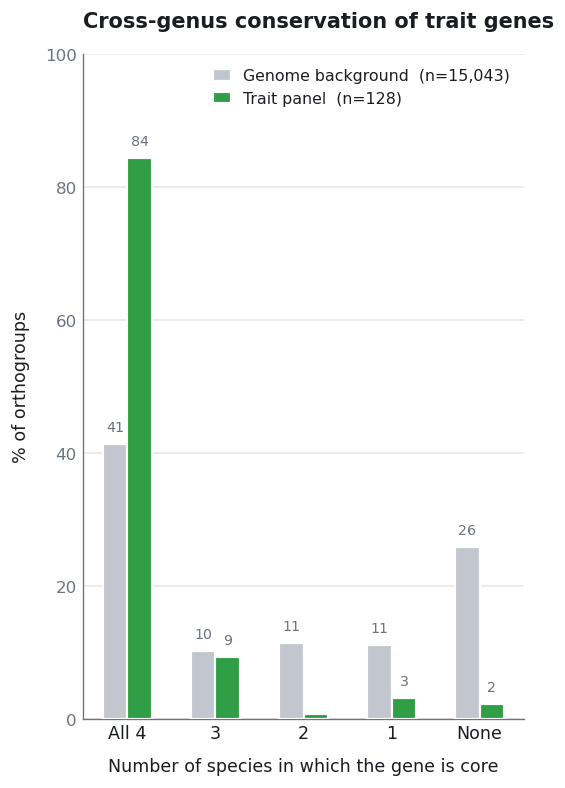

In [9]:
fig_val_cons, conservation_stats = fpcore.plot_validated_conservation(
    VAL, genus_class, NB5_RESULTS
)
plt.show()

### 3.3 Combined figure

- The variable genes over the genes shared between *A. flavus* and *A. oryzae*, with the species of characterisation outlined
- Saved to `NB5_Results/fig5bc_combined.png`

Fig 5.bc combined saved (+ curated-species blue boxes)


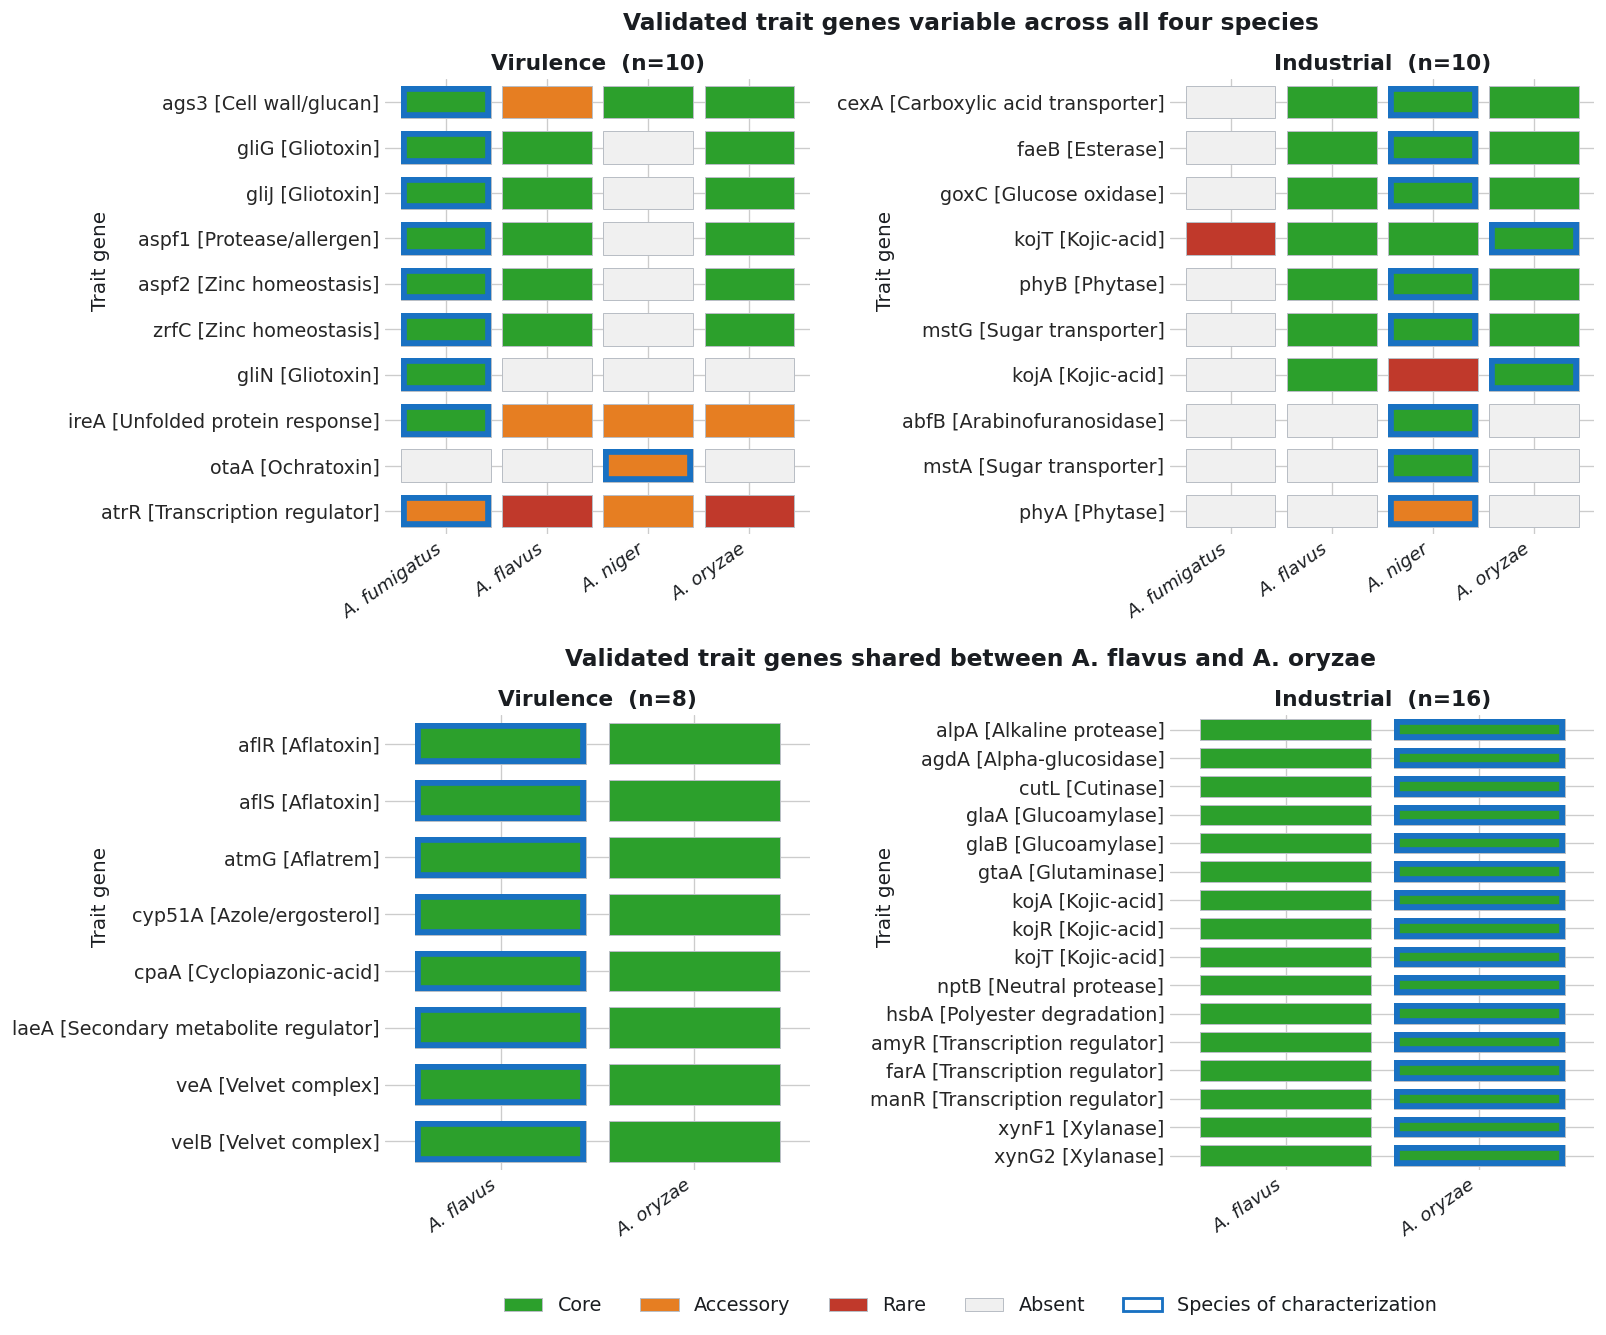

In [10]:
fig_val_combined = fpcore.plot_validated_combined(VAL, NB5_RESULTS)
plt.show()

---
## Section 4: Summary

- Panel, anchoring and conservation counts
- Every output file with its full path under `NB5_Results/`

In [11]:
# Standalone bootstrap: run this cell to use Section 4 from a fresh kernel.
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB5_RESULTS  = ANALYSIS_DIR / 'NB5_Results'
PANEL_DIR    = NB5_RESULTS / 'panels'
CACHE_DIR    = NB5_RESULTS / 'cache'
FILTERED_DIR = NB5_RESULTS / 'filtered'

# Combined four-species OrthoFinder run
COMBINED_OF        = SPECIES_ROOT / 'all_combined' / 'orthofinder_output' / 'Results_Apr08'
COMBINED_GENECOUNT = COMBINED_OF / 'Orthogroups' / 'Orthogroups.GeneCount.tsv'
COMBINED_OG_TSV    = COMBINED_OF / 'Orthogroups' / 'Orthogroups.tsv'
REF_PROT_DIR       = SPECIES_ROOT / 'all_combined' / 'orthofinder_output' / 'input_proteins'

REFERENCE_GENOMES = {
    'fumigatus': 'fumigatus__GCF_000002655.1_ASM265v1.proteins',
    'flavus':    'flavus_ani_filtered__GCF_014117465.1_ASM1411746v1.proteins',
    'niger':     'niger_ani_filtered__GCF_000002855.4_ASM285v2.proteins',
    'oryzae':    'oryzae__GCF_000184455.2_ASM18445v3.proteins',
}

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_core as fpcore

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

SPECIES_LIST = fpu.SPECIES_LIST
PATHOGENS    = ['fumigatus', 'flavus']
INDUSTRIAL   = ['niger', 'oryzae']

# Put the interpreter's directory on PATH so blastp and makeblastdb are found
_ENV_BIN = os.path.dirname(sys.executable)
if _ENV_BIN not in os.environ.get('PATH', '').split(os.pathsep):
    os.environ['PATH'] = _ENV_BIN + os.pathsep + os.environ.get('PATH', '')

In [12]:
summary_counts, summary_files = fpcore.print_nb5_summary(NB5_RESULTS)
display(summary_counts)

Core-genome outputs under /datadrive/Analysis/NB5_Results
  present: 33/33
  OK /datadrive/Analysis/NB5_Results/core_compartment_summary.csv
  OK /datadrive/Analysis/NB5_Results/core_characterization.png
  OK /datadrive/Analysis/NB5_Results/panel_orthogroup_anchoring.csv
  OK /datadrive/Analysis/NB5_Results/panel_cross_species_conservation.csv
  OK /datadrive/Analysis/NB5_Results/panel_cross_species_heatmap.png
  OK /datadrive/Analysis/NB5_Results/conservation_spectrum.png
  OK /datadrive/Analysis/NB5_Results/panel_class_by_category_bw.png
  OK /datadrive/Analysis/NB5_Results/cross_species_conservation_matrix.csv
  OK /datadrive/Analysis/NB5_Results/cross_species_conservation_matrix.png
  OK /datadrive/Analysis/NB5_Results/fig_optionA_stacked_bars.png
  OK /datadrive/Analysis/NB5_Results/fig_optionB_donut_table.png
  OK /datadrive/Analysis/NB5_Results/fig_optionC_spectrum_exceptions.png
  OK /datadrive/Analysis/NB5_Results/fig_optionD_upset.png
  OK /datadrive/Analysis/NB5_Results/shar

,table,genes,orthogroups,core in all 4,% core in all 4
0,anchored panel,412,320,326,79.1
1,SUP-filtered panel,209,177,157,75.1
2,validated panel,128,120,108,84.4
